Here, we filter the mspertscore anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 


[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


[pyKeOps] Compiling nvrtc binder for python ... 


[KeOps] Warning : There were warnings or errors :
In file included from /nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/pykeops/common/keops_io/pykeops_nvrtc.cpp:8:
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/keops_nvrtc.cpp:17:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

<span style="color:red; font-weight:bold">Delete This:</span>


In [4]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

# Preprocessing:

In [5]:
from scLEMBAS.pertpy_mixscape import Mixscape
from scipy.sparse import csr_matrix, save_npz, load_npz

In [6]:
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

In [7]:
# ms = Mixscape()
# adata = ms.perturbation_signature(
#     adata = adata, 
#     pert_key = 'drug',
#     control = 'DMSO_TF', 
#     ref_selection_mode = 'nn', # use nearest control neighbors
#     split_by = 'plate', # do within replicates
#     n_neighbors = 20, # default recommendation from Mixscape
#     use_rep = 'X_pca', # calculated on PC space determines from log1p HVGs, as in original Mixscape
#     n_dims = adata.uns['pca']['pca_rank'], 
#     batch_size = None, #int(adata.n_obs/10), # compute in batches for memory, 
#     copy = True, 
#     **{
#         'random_state': seed, 
#         'n_jobs': n_cores, 
#         'verbose': True
#     }
# )
# save_npz(os.path.join(data_path, 'interim', author + '_temp_X_pert.npz'), adata_pert.layers["X_pert"])

adata.X = load_npz(os.path.join(data_path, 'interim', author + '_temp_X_pert.npz'))

In [8]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

# Embeddings

In [9]:
covariate_associations = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito']

## PCA Space

Get the dimensionality reduction on the perturbation signature:

Note a discrepancy here: pertpy scales AND zero-centers the DE-subsetted perturbation signature (in the mixscape method), whereas the original Mixscape only zero-centers the entire matrix without subsetting. We will proceed with the pertpy implementation for simplicity. We run PCA on the HVGs identified from the expression matrix as in the Mixscape paper. 


In [10]:
file_prefix = os.path.join(data_path, 'processed', author + '_mspertscore_activity_pca')

In [11]:
adata, r2_df = ls.pc_pipeline(
    adata = adata,
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pcakwrgs': {
            'use_highly_variable': True, # identified in log-normalized data
            'zero_center': True
        }    
    }
)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/latent_separation.py:282: UserWarning: Cannot reproduce scanpy pca projection
  warnings.warn('Cannot reproduce scanpy pca projection')


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


cell_line


  0%|                                                                                                | 0/11 [00:00<?, ?it/s]

...

 73%|████████████████████████████████████████████████████████████████                        | 8/11 [04:35<01:35, 31.97s/it]

 82%|████████████████████████████████████████████████████████████████████████                | 9/11 [05:16<01:09, 34.88s/it]

 91%|███████████████████████████████████████████████████████████████████████████████        | 10/11 [05:57<00:36, 36.90s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [06:42<00:00, 39.32s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [06:42<00:00, 36.60s/it]

Elbow selection:

The elbow was automatically identified at PC 11


''

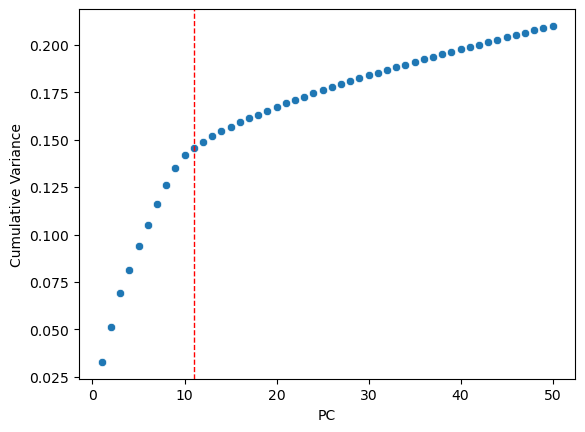

In [12]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(adata.uns['pca']['variance_ratio']),
    x=range(1, adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

The two PC components that best univariately separate by drug are components 11 and 9 explaining 18.29% and 5.19% of variance, respectively
The two PC components that best univariately separate by cell_line are components 1 and 5 explaining 94.34% and 91.42% of variance, respectively


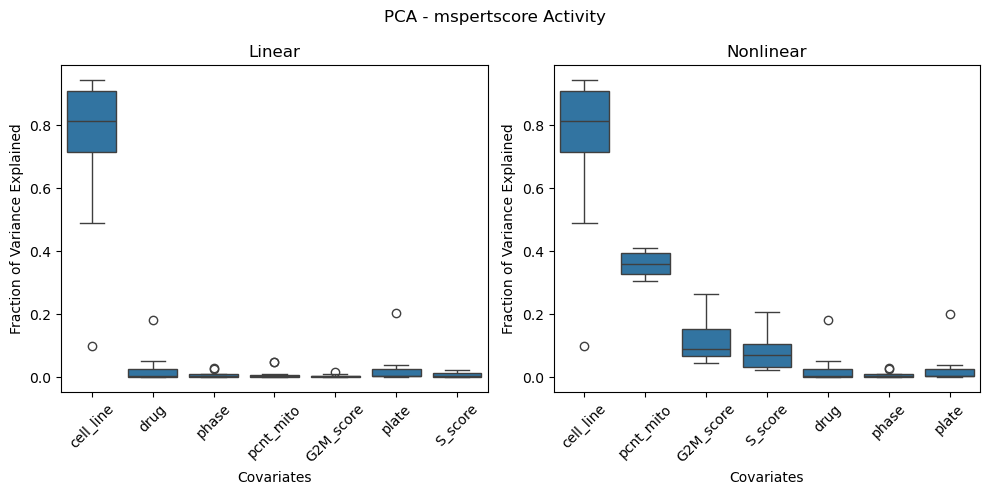

In [13]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - mspertscore Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [14]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     S_score    0.002601
           plate      0.004023
           G2M_score  0.004494
           pcnt_mito  0.004776
           phase      0.004785
           drug       0.005607
           cell_line  0.813609
nonlinear  plate      0.004023
           phase      0.004785
           drug       0.005607
           S_score    0.071248
           G2M_score  0.089589
           pcnt_mito  0.358669
           cell_line  0.813609

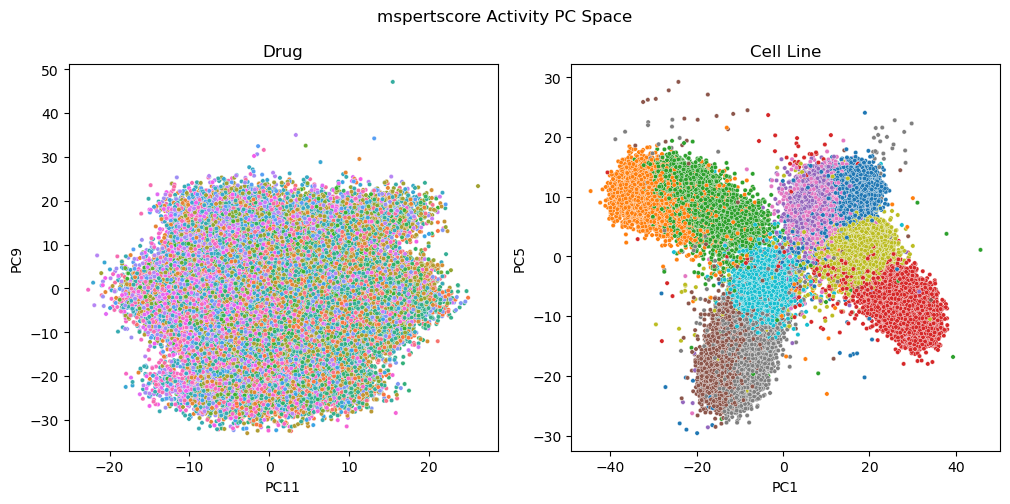

In [15]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pca', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'mspertscore Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

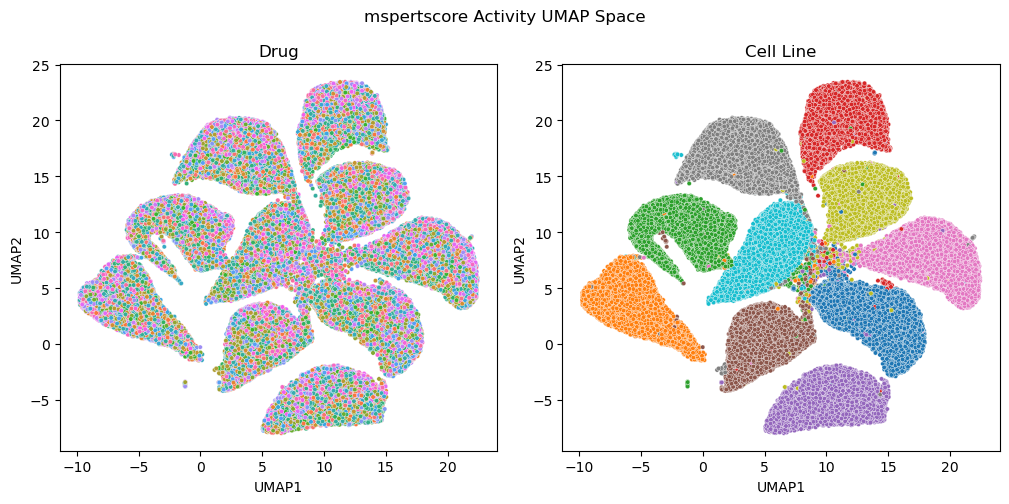

In [16]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'mspertscore Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

## PLS-DA 

For PLS-DA:
- again, we do not scale since the input is normalized
- we use our automated elbow analysis to identify the number of covariates
- umap is run categorically on drug
- we filter for HVGs for compute time (and bc this is more comparable with PCA)

In [17]:
file_prefix = os.path.join(data_path, 'processed', author + '_mspertscore_activity_pls')
filter_hvgs_pls = True

In [18]:
if filter_hvgs_pls:
    adata = adata[:, adata.var['highly_variable']]

In [19]:
adata, r2_df = ls.pls_da_pipeline(
    adata = adata, 
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # mspertscore activity already Z-scored
    run_umap = True, 
    file_prefix = file_prefix, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Run elbow selection


  0%|                                                                                                | 0/25 [00:00<?, ?it/s]

  4%|███▍                                                                                 | 1/25 [09:14<3:41:51, 554.67s/it]

  8%|██████▊                                                                              | 2/25 [18:13<3:29:08, 545.58s/it]

 12%|██████████▏                                                                          | 3/25 [26:55<3:16:05, 534.79s/it]

...

 93%|█████████████████████████████████████████████████████████████████████████████████▏     | 14/15 [08:04<00:36, 36.83s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 15/15 [08:38<00:00, 36.05s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 15/15 [08:38<00:00, 34.60s/it]


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Get UMAP


In [20]:
adata.uns['pls']['model_fit']

{'n_components': 15,
 'accuracy': 0.20910501599401074,
 'explained_y': 0.07519993271776748}

''

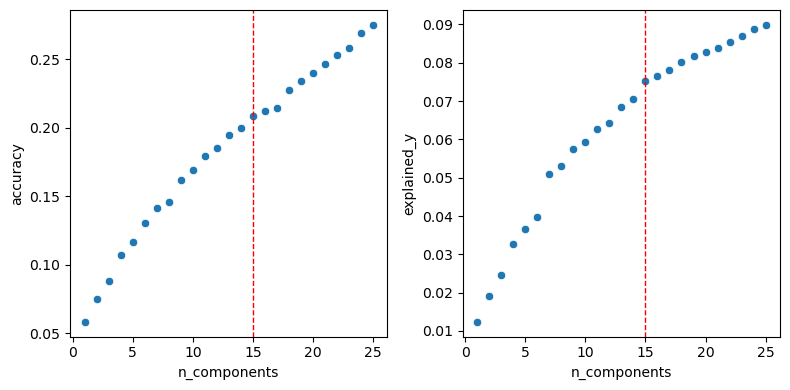

In [21]:
elbow_df = adata.uns['pls']['elbow_analysis']

n_components = adata.uns['pls']['model_fit']['n_components']
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for (i, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = elbow_df, x = 'n_components', y = metric, ax = ax[i])
    ax[i].axvline(x=n_components, color='red', linestyle='--', linewidth=1)
   
    
fig.tight_layout()
;

The two PLS components that best univariately separate by drug are components 1 and 7 explaining 42.08% and 37.80% of variance, respectively
The two PLS components that best univariately separate by cell_line are components 8 and 5 explaining 75.42% and 69.56% of variance, respectively


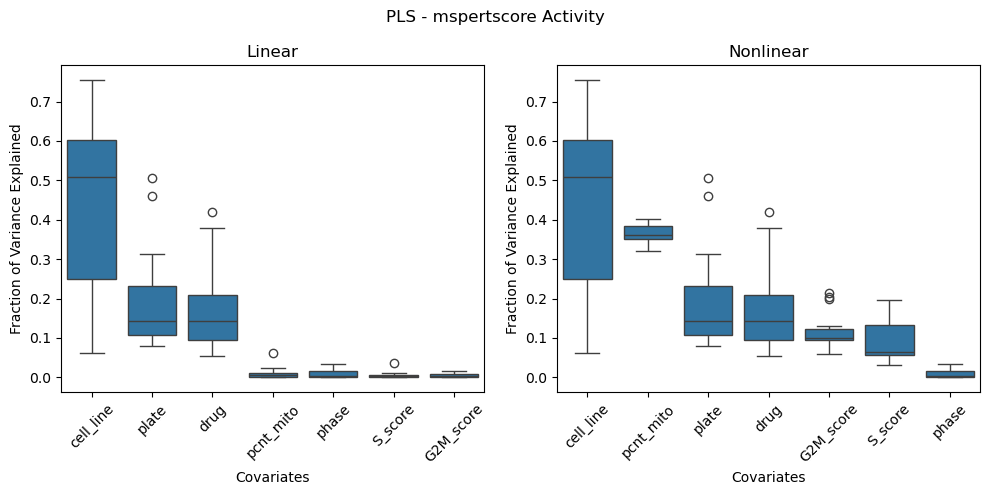

In [22]:
top_components = ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PLS - mspertscore Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [23]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     G2M_score  0.002587
           S_score    0.003136
           phase      0.004571
           pcnt_mito  0.004629
           drug       0.142268
           plate      0.143624
           cell_line  0.507717
nonlinear  phase      0.004571
           S_score    0.064231
           G2M_score  0.100181
           drug       0.142268
           plate      0.143624
           pcnt_mito  0.360886
           cell_line  0.507717

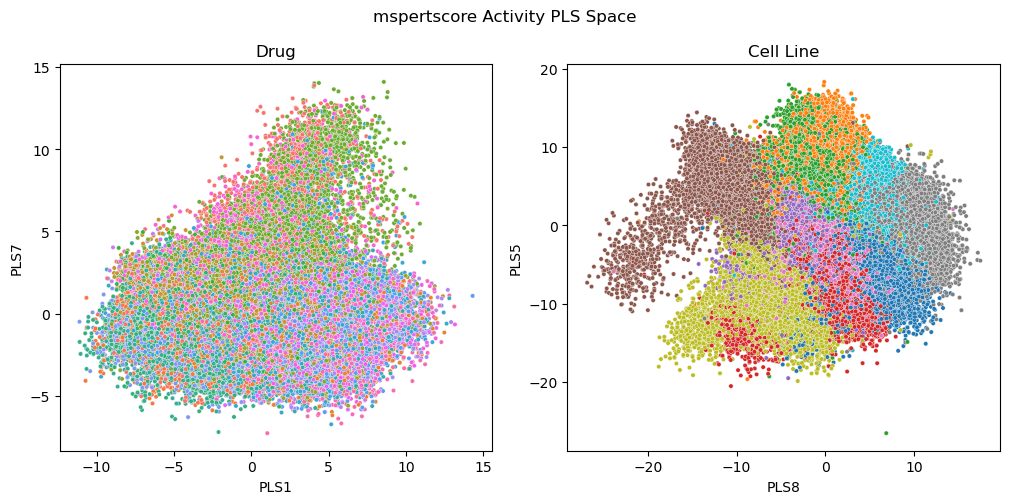

In [24]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'mspertscore Activity PLS Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

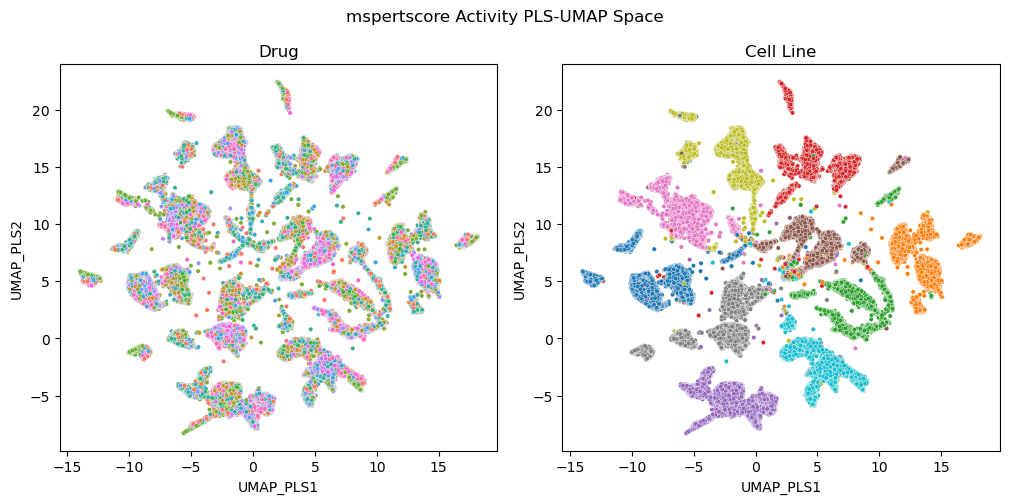

In [25]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'mspertscore Activity PLS-UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)